In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
from ctw.tree import Tree, view_tree, TreeNode, __visualize_tree
from ctw.models import Quantizer
from ctw.series import AR
from matplotlib import pyplot as plt

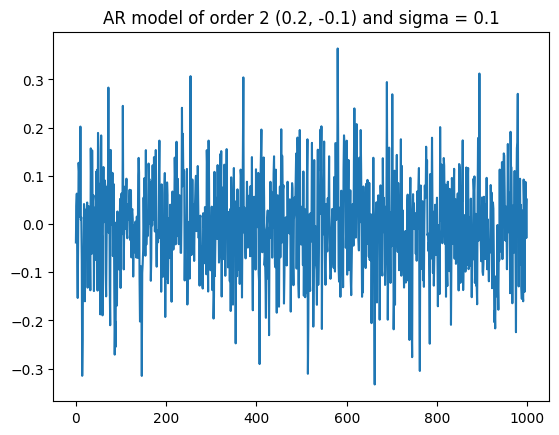

In [23]:
from ctw.series import AR

from matplotlib import pyplot as plt

p = 2
phi_1, phi_2 = 0.2, -0.1
sigma = 0.1

ar_model = AR(p = p, coeffs= [phi_1, phi_2], sigma =sigma, n_sample=1000)
x = [data for data in ar_model]
plt.title(f"AR model of order {p} {(phi_1, phi_2)} and sigma = {sigma}")
plt.plot(x);


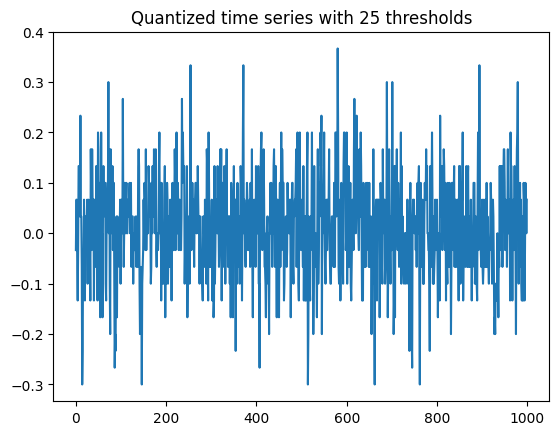

In [24]:
import numpy as np
thresholds = np.linspace(-0.4, 0.4, 25)
quantizer = Quantizer(thresholds=thresholds)

quantized_x = [quantizer.quantize(xi) for xi in x]

unquantized_x = [quantizer.unquantize(qi) for qi in quantized_x]
plt.title(f"Quantized time series with {len(thresholds)} thresholds")
plt.plot(unquantized_x);


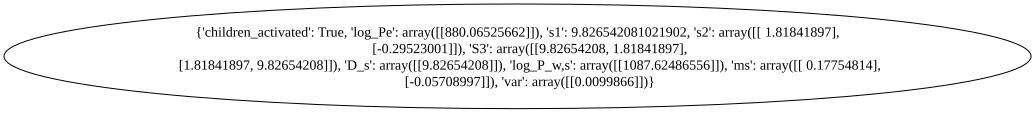

In [25]:
ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
ar_tree.build_from_string(x[:5])
ar_tree.compute_ctw(x)
# view_tree(ar_tree.tree)
ar_tree.compute_bct(x)
# view_tree(ar_tree.tree)
ar_tree.compute_map_parameters()
view_tree(ar_tree.tree)



In [26]:
from ctw.models import LiveARTree

# view_tree(live_ar_tree.tree)

In [27]:
live_ar_tree = LiveARTree(max_depth=2, order=2, quantizer=quantizer)
y = x[::]
for x_i in y:
    live_ar_tree.observe(x_i)

# ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
# ar_tree.build_from_string(y)
# ar_tree.compute_ctw(y)
# ar_tree.compute_bct(y)
# ar_tree.compute_map_parameters()

# view_tree(ar_tree.tree)

a
b


In [28]:
view_tree(live_ar_tree.tree)
# print(live_ar_tree.tree.root.data)

In [19]:
view_tree(ar_tree.tree)

[0.20604454289082855, 0.07729753503970048, -0.17714182551094493, -0.14721157351554004, 0.14965840806303277, 0.05447860875430211, -0.01264923282581789, -0.1259006474091886, -0.5224406196581592, 0.1142452344121139]
{'context': [], 'log_P_w,s': array([[307.97070072]]), 'log_P_m,s': array([[307.97070072]]), 'BS_len': 2000, 's1': 83.11433187914318, 's2': array([[  5.68139924],
       [-16.60497045]]), 'S3': array([[83.06258385,  5.73510736],
       [ 5.73510736, 83.00684139]]), 'log_Pe': array([[308.32737566]]), 'ms': array([[ 0.08260404],
       [-0.20574819]]), 'var': array([[0.04247222]]), 'sum_log_P_w,s_children': array([[-145.21654524]]), 'sum_log_P_m,s_children': array([[12.76808601]]), 'leaf_ctw': False, 'leaf_cbct': True, 'D_s': array([[83.11433188]])}


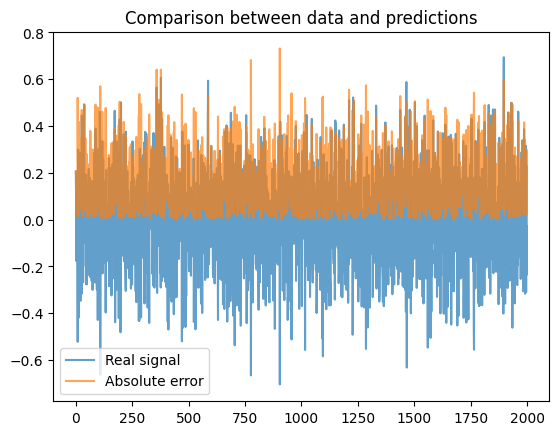

In [ ]:
x = [x_i for x_i in AR(p=2, coeffs=[0.1, -0.2], sigma=0.2, n_sample=2000)]
quantizer = Quantizer(thresholds=np.linspace(-0.5, 0.5, 20))

plt.plot(x, label = "Real signal", alpha = 0.7)
print(x[:10])
# Draw error curve between predicted and actual values
live_ar_tree = LiveARTree(max_depth=2, order=2, quantizer=quantizer)
predictions = []
actuals = []
for x_i in x:
    prediction = live_ar_tree.predict_cctw(live_ar_tree._x[-2:])
    predictions.append(prediction)
    actuals.append(x_i)
    live_ar_tree.observe(x_i)
    
errors = [abs(p - a) for p, a in zip(predictions, actuals)]
plt.plot(errors, label = "Absolute error", alpha = 0.7)
plt.legend()
plt.title("Comparison between data and predictions")

# print(live_ar_tree.predict([0, -1]))

## Compute rmse between predictions and actuals
predictions = np.array(predictions)
actuals = np.array(actuals)
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
print(f"RMSE: {rmse}")

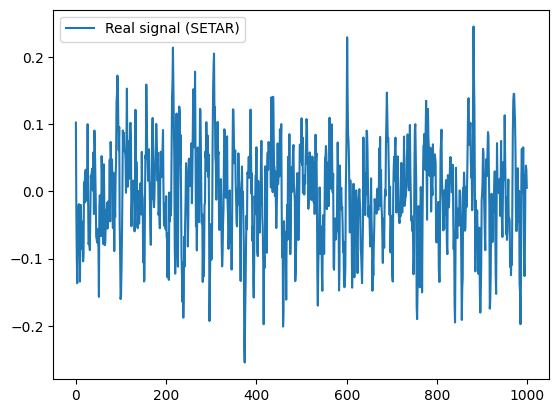

In [15]:
import numpy as np

def generate_setar_data(n_samples=2000, threshold=0.0, delay=1, sigma=0.1):
    """
    Generates data from a 2-regime SETAR model.
    Regime 1 (Low): x_t = 0.8 * x_{t-1} - 0.2 * x_{t-2} + eps
    Regime 2 (High): x_t = -0.5 * x_{t-1} + eps
    """
    p = 1  # Max order
    x = np.zeros(n_samples + p)
    
    # Coefficients for the two regimes
    phi_low = np.array([0.8, -0.2])
    phi_high = np.array([-0.5, 0.0]) # AR(1) effectively
    
    for t in range(p, n_samples + p):
        # The 'Self-Exciting' part: check the value at the delay lag
        z_t = x[t - delay]
        
        noise = np.random.normal(0, sigma)
        
        if z_t <= threshold:
            # Regime 1 logic
            x[t] = phi_low[0] * x[t-1] + phi_low[1] * x[t-2] + noise
        else:
            # Regime 2 logic
            x[t] = phi_high[0] * x[t-1] + phi_high[1] * x[t-2] + noise
            
    return x[p:]

# Generate and visualize
setar_series = generate_setar_data(n_samples=1000, threshold=0.5, sigma=0.05)
plt.plot(setar_series, label = "Real signal (SETAR)")
plt.legend()

quantizer = Quantizer(thresholds=np.linspace(-1.0, 1.0, 50))
ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
ar_tree.build_from_string(setar_series)
ar_tree.compute_ctw(setar_series)
ar_tree.compute_bct(setar_series)
ar_tree.compute_map_parameters()
view_tree(ar_tree.tree)
